In [2]:
#importação de bibliotecas
import pandas as pd
import numpy as np
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


In [3]:
#Carregando arquivo

pasta = Path(r'C:\Users\rehfe\Desktop\Curso\Analise com python\Case VAREJO\Base csv')
arquivo = pasta / 'Base Varejo.csv'

df_var = pd.read_csv(arquivo, sep=';')
df_var = df_var.drop(columns=['Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13'])

print('dados carregados')


dados carregados


In [4]:
# Informações básicas do dataset
print(f" O dataset tem {df_var.shape[0]} linhas e {df_var.shape[1]} colunas")
print()
print("📋 Tipo de dado de cada coluna:")
print(df_var.dtypes)
print(df_var.describe())

 O dataset tem 830000 linhas e 10 colunas

📋 Tipo de dado de cada coluna:
DATA           str
CO_ID        int64
CL_ID        int64
CL_GENERO      str
CL_EC        int64
CL_FHL       int64
CL_SEG         str
PR_ID        int64
PR_CAT         str
PR_NOME        str
dtype: object
              CO_ID          CL_ID          CL_EC        CL_FHL          PR_ID
count  830000.00000  830000.000000  830000.000000  830000.00000  830000.000000
mean   460045.08989     499.595204       2.596911       1.14654     115.051855
std    265465.24754     287.568253       1.170599       1.41696      66.129241
min      1000.00000       1.000000       1.000000       0.00000       1.000000
25%    233117.00000     254.000000       2.000000       0.00000      58.000000
50%    456517.00000     498.000000       3.000000       0.00000     115.000000
75%    690132.00000     746.000000       4.000000       2.00000     172.000000
max    919822.00000    1000.000000       5.000000       4.00000     229.000000


In [5]:
#Tratar nulos
print(df_var.isnull().sum())
print()
df_var = df_var.replace({'NULL': np.nan, 'N/A': np.nan, '': np.nan,'#N/D': 'OUTROS'})
print(df_var.isnull().sum())
print()

# Verificar string vazia
df_vazia = df_var['PR_NOME'].str.strip() == ''
print("Após str.strip() == '': ", df_vazia.sum(), "vazios")


DATA         0
CO_ID        0
CL_ID        0
CL_GENERO    0
CL_EC        0
CL_FHL       0
CL_SEG       0
PR_ID        0
PR_CAT       0
PR_NOME      0
dtype: int64

DATA         0
CO_ID        0
CL_ID        0
CL_GENERO    0
CL_EC        0
CL_FHL       0
CL_SEG       0
PR_ID        0
PR_CAT       0
PR_NOME      0
dtype: int64

Após str.strip() == '':  0 vazios


In [6]:
#Tratar colunas duplicadas
print(f"Linhas completamente iguais: {df_var.duplicated().sum()}")
print()
df_var2 = df_var.drop_duplicates()
print(f"Linhas completamente iguais: {df_var2.duplicated().sum()}")
print()
print(f" O dataset tem {df_var2.shape[0]} linhas e {df_var2.shape[1]} colunas")

Linhas completamente iguais: 96553

Linhas completamente iguais: 0

 O dataset tem 733447 linhas e 10 colunas


In [7]:
#Fomartar a coluna data para datetime
print(df_var2.dtypes)
print()
df_var2['DATA_MOD'] = pd.to_datetime(df_var2['DATA'], format='%d/%m/%Y', errors='coerce')
print(df_var2.dtypes)

DATA           str
CO_ID        int64
CL_ID        int64
CL_GENERO      str
CL_EC        int64
CL_FHL       int64
CL_SEG         str
PR_ID        int64
PR_CAT         str
PR_NOME        str
dtype: object

DATA                    str
CO_ID                 int64
CL_ID                 int64
CL_GENERO               str
CL_EC                 int64
CL_FHL                int64
CL_SEG                  str
PR_ID                 int64
PR_CAT                  str
PR_NOME                 str
DATA_MOD     datetime64[us]
dtype: object


In [8]:
# Filtra as linhas onde a data é inválida isna()
linhas_invalidas = df_var2[df_var2['DATA_MOD'].isna()]
print(linhas_invalidas)

Empty DataFrame
Columns: [DATA, CO_ID, CL_ID, CL_GENERO, CL_EC, CL_FHL, CL_SEG, PR_ID, PR_CAT, PR_NOME, DATA_MOD]
Index: []


In [9]:
#Estatísticas descritivas da coluna filhos
print(df_var2['CL_FHL'].describe().map('{:,.2f}'.format))

count    733,447.00
mean           1.15
std            1.42
min            0.00
25%            0.00
50%            0.00
75%            2.00
max            4.00
Name: CL_FHL, dtype: str


In [10]:
#Configura para o padrão do Brasil
import locale
locale.setlocale(locale.LC_ALL, 'pt_BR.utf8')

'pt_BR.utf8'

In [ ]:
#Analise da qtd de produtos vendidos por genero
QTD_GEN = pd.pivot_table(
    df_var2,
    values="PR_ID",
    index="CL_GENERO",  
    aggfunc="count",       
    fill_value=0         
)

QTD_GEN = QTD_GEN / 1000
print(QTD_GEN.map('{:,.0f}K'.format))
print()


          PR_ID
CL_GENERO      
F          382K
M          351K



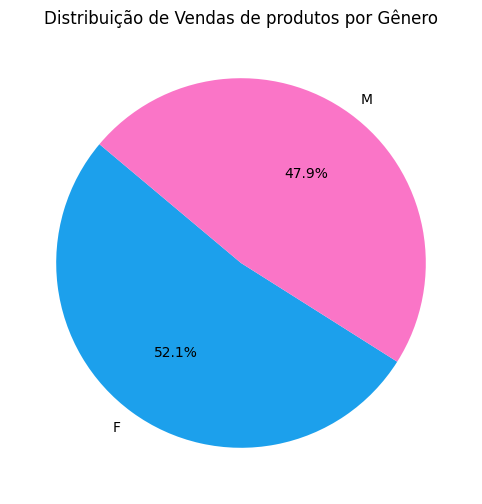

In [119]:
#Gráfico de pizza para a distribuição de vendas de produtos por gênero
cores = ["#1CA0EC","#FA75C7"]

QTD_GEN.plot.pie(
    y="PR_ID", 
    autopct='%.1f%%', 
    figsize=(8, 6),
    colors=cores,        
    startangle=140,
    legend=False 
)

plt.title('Distribuição de Vendas de produtos por Gênero')
plt.ylabel('')             
plt.show()

In [ ]:
#Analise de qtd vendas de produtos por categoria
QTD_CAT = pd.pivot_table(
    df_var2,
    values="PR_ID",
    index="PR_CAT",  
    aggfunc="count",     
    fill_value=0
)

QTD_CAT = QTD_CAT / 1000
print(QTD_CAT.map('{:,.0f}K'.format))


           PR_ID
PR_CAT          
ACESSORIOS   13K
ALIMENTOS   384K
BEBIDAS      38K
HIGIENE     138K
LIMPEZA     129K
OUTROS        3K
PET          29K


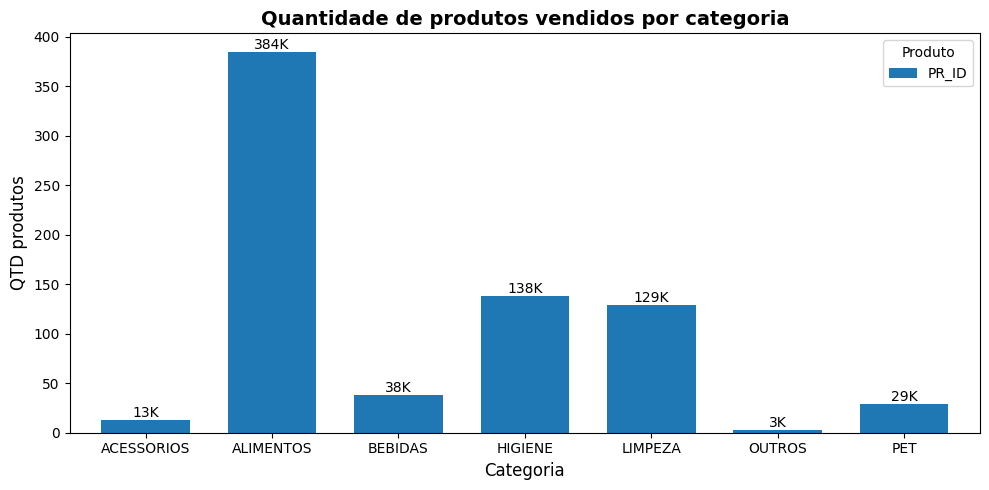

In [ ]:
#Gráfico de barras para a distribuição de vendas de produtos por categoria

fig, ax = plt.subplots(figsize=(10, 5))

grafico = QTD_CAT.plot(kind='bar',ax=ax, stacked=True, width=0.7)


ax.set_title('Quantidade de produtos vendidos por categoria', fontsize=14, fontweight='bold')
ax.set_xlabel('Categoria', fontsize=12)
ax.set_ylabel('QTD produtos', fontsize=12)

ax.bar_label(ax.containers[0], label_type="edge", color='black', fmt='{:,.0f}K')
if len(ax.containers) > 1:
    ax.bar_label(ax.containers[1], label_type="edge", color='black', fmt='R${:,.2f}K')

plt.xticks(rotation=0)
plt.legend(title='Produto')
plt.tight_layout()
plt.show()

In [15]:
#acrescenta coluna mês e ano

df_var2['MES'] = df_var2['DATA_MOD'].dt.strftime('%b')
df_var2['ANO'] = df_var2['DATA_MOD'].dt.year
#print(df_var2.head())

In [ ]:
#Analise de qtd de produtos vendidos por mês
QTD_VEN = pd.pivot_table(
    df_var2,
    values="PR_ID",
    index="MES",  
    aggfunc="count",      
    fill_value=0, 
    margins=True,
    margins_name='Total Geral'       
)

QTD_VEN = QTD_VEN.reindex(index=['jan', 'fev', 'mar', 'abr', 'mai', 'jun', 'jul', 'ago', 'set', 'out', 'nov', 'dez'])
QTD_VEN = QTD_VEN / 1000
print(QTD_VEN.map('{:,.0f}K'.format))
print()


    PR_ID
MES      
jan   74K
fev   67K
mar   57K
abr   59K
mai   73K
jun   60K
jul   61K
ago   58K
set   61K
out   65K
nov   36K
dez   62K



In [ ]:
#Analise de qtd de produtos vendidos ao longo dos anos
QTD_VEN_2 = pd.pivot_table(
    df_var2,
    values="PR_ID",
    index="ANO", 
    aggfunc="count",      
    fill_value=0      
)

QTD_VEN_2 = QTD_VEN_2 / 1000
print(QTD_VEN_2.map('{:,.0f}K'.format))
print()


     PR_ID
ANO       
2019  176K
2020  193K
2021  217K
2022  148K



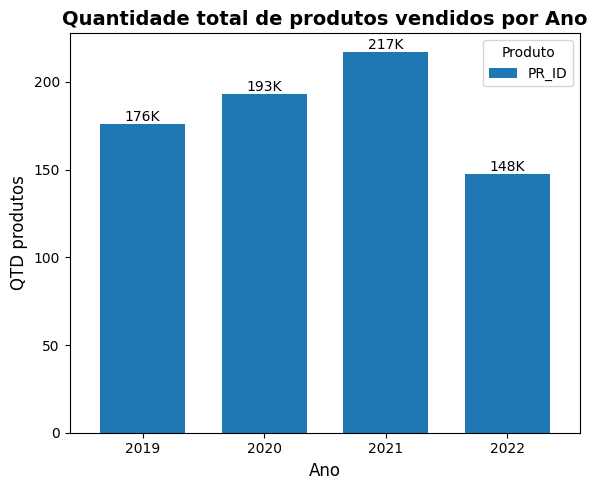

In [ ]:
#Gráfico de barras para a distribuição de vendas de produto por ano
fig, ax = plt.subplots(figsize=(6, 5))

grafico = QTD_VEN_2.plot(kind='bar',ax=ax, stacked=True, width=0.7)


ax.set_title('Quantidade total de produtos vendidos por Ano', fontsize=14, fontweight='bold')
ax.set_xlabel('Ano', fontsize=12)
ax.set_ylabel('QTD produtos', fontsize=12)

ax.bar_label(ax.containers[0], label_type="edge", color='black', fmt='{:,.0f}K')
if len(ax.containers) > 1:
    ax.bar_label(ax.containers[1], label_type="edge", color='black', fmt='{:,.0f}K')

plt.xticks(rotation=0)
plt.legend(title='Produto')
plt.tight_layout()
plt.show()

In [120]:
#Analise da qtd de produtos vendidos por categoria anual
QTD_CAT_2 = pd.pivot_table(
    df_var2,
    values="PR_ID",
    columns="ANO",
    index="PR_CAT",  
    aggfunc="count",     
    fill_value=0
)

QTD_CAT_2 = QTD_CAT_2 / 1000

print(QTD_CAT_2.map('{:,.0f}K'.format))

ANO        2019  2020  2021 2022
PR_CAT                          
ACESSORIOS   3K    3K    4K   3K
ALIMENTOS   92K  101K  114K  77K
BEBIDAS      9K   10K   11K   8K
HIGIENE     33K   36K   41K  28K
LIMPEZA     31K   34K   38K  26K
OUTROS       1K    1K    1K   1K
PET          7K    8K    8K   6K


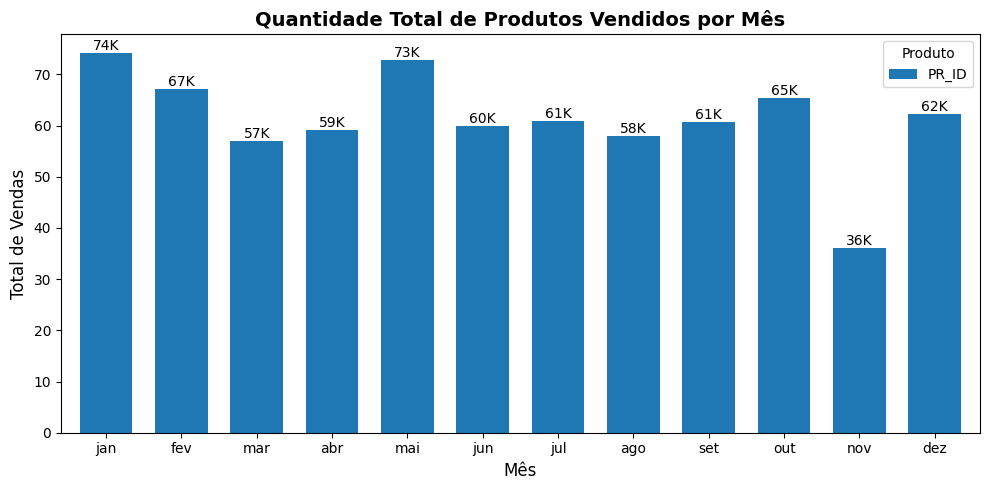

In [121]:
#Gráfico de barras para a distribuição de vendas de produtos por mês
fig, ax = plt.subplots(figsize=(10, 5))

grafico = QTD_VEN.plot(kind='bar',ax=ax, stacked=True, width=0.7)


ax.set_title('Quantidade Total de Produtos Vendidos por Mês', fontsize=14, fontweight='bold')
ax.set_xlabel('Mês', fontsize=12)
ax.set_ylabel('Total de Vendas', fontsize=12)

ax.bar_label(ax.containers[0], label_type="edge", color='black', fmt='{:.0f}K')
if len(ax.containers) > 1:
    ax.bar_label(ax.containers[1], label_type="edge", color='black', fmt='{:.0f}K')

plt.xticks(rotation=0)
plt.legend(title='Produto')
plt.tight_layout()
plt.show()